# Project Checkpoint 1: Dataset Comparison, Selection, and EDA

## A. Identification of Candidate Datasets

By searching on the website, I have found the following three datasets.

### 1. Recipe Reviews and User Feedback
  - Dataset name and source
    - Name: Recipe Reviews and User Feedback Dataset
    - Source: UCI Machine Learning Repository https://archive.ics.uci.edu/dataset/911/recipe+reviews+and+user+feedback+dataset.
  - Course topic alignment
    - Text mining and embeddings: We can use the review `text` for sentiment, clustering, similarity search, and feature engineering.
  - Potential beyond-course techniques
    - Transformer-based embeddings: We can create Sentence-BERT style embeddings for reviews, and then do clustering or semantic retrieval.
  - Dataset size and structure
    - Rows: 18182 review records
    - Columns: 15
    - Entities: 100 unique recipes, 13812 unique users
    - Structure: One row per user comment on a recipe, with engagement counters and an integer rating.
  - Data types
    - Integer features: `num_records`, `recipe_number`, `recipe_code`, `user_reputation`, `created_at`, `reply_count`, `thumbs_up`, `thumbs_down`, `stars`, `best_score`
    - Categorical features: `recipe_name`, `comment_id`, `user_id`, `user_name`, `text`
  - Target variable(s)
    - Unsupervised text mining: None
  - Licensing or usage constraints
    - This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license. We can use and adapt it, but we must provide attribution.


### 2. Douban Online Social Network
  - Dataset name and source
    - Name: soc-douban (Douban online social network)
    - Source: Network Repository https://networkrepository.com/soc-douban.php.
  - Course topic alignment
    - Graph mining, PageRank, community detection
  - Potential beyond-course techniques
    - Graph representation learning: we can use node2vec, DeepWalk, or LINE for node embeddings, and then do clustering or link prediction.
  - Dataset size and structure
    - Nodes: 154.9K
    - Edges: 327.2K
    - Structure: Average degree as 4 with low density and modest clustering, plus many triangles.
  - Data types
    - Node IDs: Integers
    - Edges: Pairs of integers per line (u, v)
  - Target variable(s)
    - Link prediction: Whether an edge exists (binary).
    - Graph mining, PageRank, and community detection: None
  - Licensing or usage constraints
    - Network Repository's policy states datasets are licensed under Creative Commons Attribution ShareAlike. We can share and adapt with attribution, and derivatives should keep the same license terms.

### 3. Online Retail
  - Dataset name and source
    - Name: Online Retail
    - Source: UCI Machine Learning Repository https://archive.ics.uci.edu/dataset/352/online+retail.
  - Course topic alignment
    - Frequent itemsets and association rule mining: We can treat each `InvoiceNo` as a basket and mine co-purchased `StockCode`s, and then generate association rules.
  - Potential beyond-course techniques
    - Sequential pattern mining: We can mine frequent sequences of purchases over time.
  - Dataset size and structure
    - Rows: 541909 line items
    - Columns: 8
    - Structure: A line-item table. Each invoice consists of multiple rows.
  - Data types
    - Categorical features: `InvoiceNo`, `StockCode`, `Description`, `CustomerID`, `Country`
    - Integer features: `Quantity`
    - Date features: `InvoiceDate`
    - Continuous features: `UnitPrice`
  - Target variable(s)
    - Unsupervised pattern mining: None
    - Association rule mining: None
  - Licensing or usage constraints
    - This dataset is licensed under a Creative Commons Attribution 4.0 International (CC BY 4.0) license. We can use and adapt it, but we must provide attribution.

On my honor, I declare the following resources:
1. Web Sources:
- https://archive.ics.uci.edu/dataset/911/recipe+reviews+and+user+feedback+dataset: Recipe Reviews and User Feedback Dataset
- https://networkrepository.com/soc-douban.php: soc-douban (Douban online social network) Dataset
- https://archive.ics.uci.edu/dataset/352/online+retail: Online Retail Dataset

2. AI Tools:
- ChatGPT: I provided the information of each dataset to ask it to suggest some beyond-course techniques.

## B. Comparative Analysis of Datasets

| Dataset | Supported data mining tasks |
|---|---|
| **Recipe Reviews and User Feedback** (UCI) | **Course:** text mining, embeddings, clustering on review text. <br> **External:** transformer-based embeddings (Sentence-BERT) |
| **Douban Online Social Network** (Network Repository) | **Course:** graph mining, PageRank, community detection. <br> **External:** node embeddings (node2vec, DeepWalk, LINE), link prediction. |
| **Online Retail** (UCI) | **Course:** frequent itemsets and association rules. <br> **External:** sequential pattern mining over time. |

| Dataset | Data quality issues |
|---|---|
| **Recipe Reviews and User Feedback** (UCI) | Text is noisy by nature (typos, short comments). <br> Minor missingness in `text`. |
| **Douban Online Social Network** (Network Repository) | Sparse graph (avg degree ~ 4), likely multiple components. <br> No node attributes, so everything is topology-based. <br> Potential sampling artifacts due to crawling. |
| **Online Retail** (UCI) | Cancellations indicated by `InvoiceNo` starting with `C`. <br> Returns often appear as negative `Quantity`. <br> Missing `CustomerID` is common in the file. <br> Potential duplicates and zero `UnitPrice` entries. |

| Dataset | Algorithmic feasibility |
|---|---|
| **Recipe Reviews and User Feedback** (UCI) | 18,182 rows is easy to process, even on a laptop. <br> Transformer embeddings are feasible on CPU with small models, faster with GPU. |
| **Douban Online Social Network** (Network Repository) | 155k nodes and 327k edges is manageable on one machine with efficient libraries and sparse matrices. <br> NetworkX may be slow for repeated heavy computations. <br> Node2vec is feasible with properly chosen parameters. |
| **Online Retail** (UCI) | 541,909 line items is feasible, but Apriori can blow up without pruning. <br> Sequential mining is heavier, use constraints like time windows and top-k. |

| Dataset | Bias considerations |
|---|---|
| **Recipe Reviews and User Feedback** (UCI) | User generated text can reflect selection bias (who chooses to comment). |
| **Douban Online Social Network** (Network Repository) | Sampling bias and missing edges. <br> Link prediction can amplify popularity effects and structural inequality. |
| **Online Retail** (UCI) | Customer and product selection bias. <br> Popular items dominate itemsets and recommendations. <br> Seasonal effects and promotions can create spurious associations. |

| Dataset | Ethical considerations |
|---|---|
| **Recipe Reviews and User Feedback** (UCI) | Avoid attempting re-identification via usernames. <br> Keep analysis aggregated and do not infer sensitive traits from text. |
| **Douban Online Social Network** (Network Repository) | Social network structure can be sensitive even if anonymized. <br> Avoid profiling or making claims about real individuals. |
| **Online Retail** (UCI) | Transaction data is sensitive. Avoid identifying customers. <br> Report aggregate findings, and be careful with country comparisons and avoid stereotyping. |

On my honor, I declare the following resources:
1. AI Tools:
- ChatGPT: I provided the dataset information to it to ask it to suggest some bias and ethical considerations.

## C. Dataset Selection


Among these three datasets, I chose the Online Retail dataset. <br>
- Reasons:
  - Directly supports frequent itemsets and association rules by treating each invoice as a shopping basket (course).
  - Supports sequential pattern mining over time, which is beyond what we covered in class (external).
  - Allows us to compare patterns from baskets with no order versus patterns that use time order.
- Trade-offs:
  - The data is not text focused, so text mining is limited to short product descriptions.
  - Many rows have missing customer IDs and there are returns and cancellations, so we must choose our assumptions carefully.

On my honor, I declare the following resources:
- None

## D. Exploratory Data Analysis (Selected Dataset Only)

### 1. Dataset Downloading and Loading

In [1]:
import os
import zipfile
from pathlib import Path
import requests

# Download
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

zip_url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
zip_path = DATA_DIR / "online_retail.zip"

def download_file(url: str, out_path: Path, chunk_size: int = 1024 * 1024) -> None:
    if out_path.exists() and out_path.stat().st_size > 0:
        print(f"Found existing file: {out_path} ({out_path.stat().st_size:,} bytes)")
        return

    with requests.get(url, stream=True, timeout=60) as r:
        r.raise_for_status()
        total = int(r.headers.get("Content-Length", 0))
        downloaded = 0

        with open(out_path, "wb") as f:
            for chunk in r.iter_content(chunk_size=chunk_size):
                if chunk:
                    f.write(chunk)
                    downloaded += len(chunk)

    print(f"Downloaded: {out_path} ({downloaded:,} bytes) of {total:,} bytes")

download_file(zip_url, zip_path)

# Unzip
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(DATA_DIR)

print("Unzipped files:")
for p in sorted(DATA_DIR.rglob("*")):
    if p.is_file():
        print(" ", p)

Downloaded: data/online_retail.zip (23,715,478 bytes) of 0 bytes
Unzipped files:
  data/Online Retail.xlsx
  data/online_retail.zip


In [2]:
import pandas as pd

# Find the first .xlsx file in the extracted folder
xlsx_files = sorted(DATA_DIR.rglob("*.xlsx"))
if not xlsx_files:
    raise FileNotFoundError("No .xlsx file found after unzipping")

xlsx_path = xlsx_files[0]
print("Loading:", xlsx_path)

df = pd.read_excel(xlsx_path)

print("Shape:", df.shape)
display(df.head())
df.info()

Loading: data/Online Retail.xlsx
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


I first download and unzip the dataset, and then load it into a pandas dataframe. By looking at the shape of the dataframe, we can find out that the dataset has 541909 rows and 8 columns, which matches what is listed on the website. We can also find that among all the 8 columns, CustomerID has a lot of missing values, which aligns with one of the limitations of this dataset that we have discussed.

On my honor, I declare the following resources:
1. AI Tools:
- ChatGPT: I provided the download link and the dataset file to it to ask it to generate code to download, unzip, and load the dataset using pandas.

### 2. Basket Size Distribution

Unique items per invoice


,count_invoices,mean,std,min,median,p90,p95,p99,max
0,19960,26.032164,46.982195,1,15.0,52.0,75.0,217.41,1110


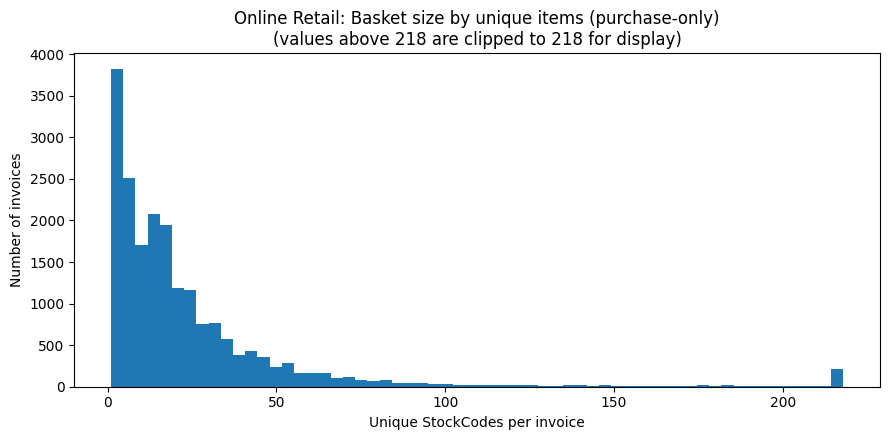

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Purchase-only filter
df["InvoiceNo"] = df["InvoiceNo"].astype(str)
is_cancellation = df["InvoiceNo"].str.startswith("C")

df_purchase = df.loc[~is_cancellation].copy()
df_purchase = df_purchase.loc[df_purchase["Quantity"] > 0].copy()
df_purchase = df_purchase.loc[df_purchase["UnitPrice"] > 0].copy()

# Drop missing or blank StockCodes just in case
df_purchase = df_purchase.dropna(subset=["InvoiceNo", "StockCode"])
df_purchase = df_purchase.loc[df_purchase["StockCode"].str.strip() != ""]

# Basket sizes
basket_unique = df_purchase.groupby("InvoiceNo")["StockCode"].nunique().rename("basket_size_unique_items")

def summarize(series: pd.Series) -> pd.DataFrame:
    return pd.DataFrame({
        "count_invoices": [int(series.shape[0])],
        "mean": [float(series.mean())],
        "std": [float(series.std(ddof=1))],
        "min": [int(series.min())],
        "median": [float(series.median())],
        "p90": [float(series.quantile(0.90))],
        "p95": [float(series.quantile(0.95))],
        "p99": [float(series.quantile(0.99))],
        "max": [int(series.max())],
    })

print("Unique items per invoice")
display(summarize(basket_unique))

# Histograms. Clip at 99th percentile so the plot shows the main mass clearly.
def plot_hist(series, title, xlabel):
    cap = int(np.ceil(series.quantile(0.99)))
    clipped = series.clip(upper=cap)

    plt.figure(figsize=(9, 4.5))
    plt.hist(clipped, bins=60)
    plt.title(f"{title}\n(values above {cap} are clipped to {cap} for display)")
    plt.xlabel(xlabel)
    plt.ylabel("Number of invoices")
    plt.tight_layout()
    plt.show()

plot_hist(basket_unique, "Online Retail: Basket size by unique items (purchase-only)", "Unique StockCodes per invoice")

I first did a basket size analysis. Here, I define a basket as an invoice (`InvoiceNo`), and I reported basket size in unique items per invoice, or in other words, the number of unqiue `StockCode` values per invoice. I did this way because if we count line items for each invoice, some line items might have duplicates. <br><br>
I also apply a standard purchase-only filter so basket sizes are not distorted by returns and cancellations. Specifically, I dropped cancellations where `InvoiceNo` starts with "C". I also kept only purchased and priced items where `Quantity > 0` and `UnitPrice > 0`. <br><br>
After purchase-only filtering, I computed some basic statistics. From these statistics, we can find that there are a total of 19960 invoices. The size of each invoice has a mean of 26.03 and a median of 15. Its 90th, 95th, and 99th percentiles are 52, 75, and 217 respectively, with a max of 1110. Combined with the basket size distribution plotting, we can see that the basket sizes are highly skewed. Most invoices are small but a few are extremely large.

On my honor, I declare the following resources:
1. AI Tools:
- ChatGPT: I asked it to generate code for basket size analysis by using the definition of an invoice as a basket, and the number of unique items per invoice as the basket size.

### 3. Frequency of top items


In [15]:
def compute_top_items(df_purchase: pd.DataFrame, top_n: int = 20):
    """
    Compute top items by invoice-level frequency (support) under a unique-items-per-invoice basket definition.

    Returns:
    invoice_item : pandas.DataFrame
        Deduplicated invoice-item table with columns ['InvoiceNo', 'StockCode', 'Description'],
        containing at most one row per (InvoiceNo, StockCode).
    item_support : pandas.DataFrame
        Item support table indexed by StockCode with:
        - 'invoice_count': number of distinct invoices containing the item
        - 'invoice_share': invoice_count divided by total number of invoices
        - 'Description': representative description for the StockCode (mode)
        Sorted by invoice_count descending.
    top_items : pandas.DataFrame
        First `top_n` rows of `item_support` as a flat table (StockCode as a column).
    n_invoices : int
        Number of distinct invoices in `invoice_item`.
    """
    # Ensure StockCode is string for consistent grouping
    df_purchase = df_purchase.copy()
    df_purchase["StockCode"] = df_purchase["StockCode"].astype(str)

    # One row per (invoice, item) to match "unique items per invoice"
    invoice_item = df_purchase[["InvoiceNo", "StockCode", "Description"]].copy()
    invoice_item["Description"] = invoice_item["Description"].astype(str).str.strip()
    invoice_item = invoice_item.drop_duplicates(subset=["InvoiceNo", "StockCode"])

    n_invoices = invoice_item["InvoiceNo"].nunique()

    # Support counts: number of invoices containing each StockCode
    item_support = (
        invoice_item.groupby("StockCode")["InvoiceNo"]
        .nunique()
        .rename("invoice_count")
        .sort_values(ascending=False)
        .to_frame()
    )
    item_support["invoice_share"] = item_support["invoice_count"] / n_invoices

    # Representative description per StockCode (most common among purchase rows)
    desc_map = (
        invoice_item.dropna(subset=["Description"])
        .groupby("StockCode")["Description"]
        .agg(lambda x: x.value_counts().index[0])
    )
    item_support = item_support.join(desc_map, how="left")

    top_items = item_support.head(top_n).reset_index()
    return invoice_item, item_support, top_items, n_invoices

invoice_item, item_support, top_items, n_invoices = compute_top_items(df_purchase, top_n=20)

print(f"Invoices (purchase-only): {n_invoices:,}")
print(f"Unique items (purchase-only): {item_support.shape[0]:,}")
display(top_items)

Invoices (purchase-only): 19,960
Unique items (purchase-only): 3,922


,StockCode,invoice_count,invoice_share,Description
0,85123A,2198,0.110120,WHITE HANGING HEART T-LIGHT HOLDER
1,85099B,2089,0.104659,JUMBO BAG RED RETROSPOT
2,22423,1988,0.099599,REGENCY CAKESTAND 3 TIER
3,47566,1685,0.084419,PARTY BUNTING
4,20725,1565,0.078407,LUNCH BAG RED RETROSPOT
5,84879,1455,0.072896,ASSORTED COLOUR BIRD ORNAMENT
6,22197,1392,0.069739,POPCORN HOLDER
7,22720,1385,0.069389,SET OF 3 CAKE TINS PANTRY DESIGN
8,21212,1320,0.066132,PACK OF 72 RETROSPOT CAKE CASES
9,22383,1284,0.064329,LUNCH BAG SUKI DESIGN


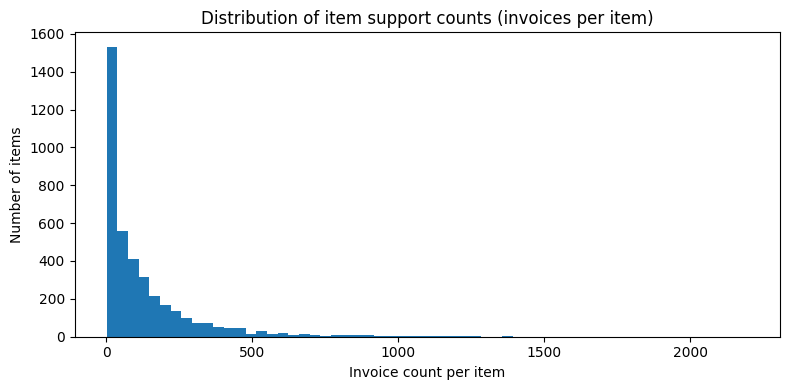

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(item_support["invoice_count"], bins=60)
plt.title("Distribution of item support counts (invoices per item)")
plt.xlabel("Invoice count per item")
plt.ylabel("Number of items")
plt.tight_layout()
plt.show()

In [6]:
# Meaningful tests

def test_support_counts_use_unique_invoice_item_pairs():
    """
    If the same (InvoiceNo, StockCode) appears multiple times, it should count once
    for support, and invoice_count should be number of invoices containing the item.
    """
    df_purchase = pd.DataFrame(
        {
            "InvoiceNo": ["A", "A", "A", "B", "B"],
            "StockCode": [101, 101, 102, 101, 103],
            "Description": ["x", "x", "y", "x", "z"],
        }
    )
    _, item_support, _, n_invoices = compute_top_items(df_purchase, top_n=10)

    assert n_invoices == 2
    # StockCode 101 appears in invoices A and B, duplicates within A should not inflate
    assert int(item_support.loc["101", "invoice_count"]) == 2
    # StockCode 102 appears only in invoice A
    assert int(item_support.loc["102", "invoice_count"]) == 1
    # StockCode 103 appears only in invoice B
    assert int(item_support.loc["103", "invoice_count"]) == 1


def test_invoice_share_is_consistent_and_bounded():
    """
    invoice_share should equal invoice_count / n_invoices, and be within [0, 1].
    Also the max share should be 1.0 if an item appears in every invoice.
    """
    df_purchase = pd.DataFrame(
        {
            "InvoiceNo": ["A", "A", "B", "B", "C"],
            "StockCode": ["X", "Y", "X", "Z", "X"],
            "Description": ["dx", "dy", "dx", "dz", "dx"],
        }
    )
    _, item_support, _, n_invoices = compute_top_items(df_purchase, top_n=10)

    assert n_invoices == 3

    # X appears in A, B, C
    assert int(item_support.loc["X", "invoice_count"]) == 3
    assert float(item_support.loc["X", "invoice_share"]) == 1.0

    # All shares must be within [0, 1]
    assert (item_support["invoice_share"] >= 0).all()
    assert (item_support["invoice_share"] <= 1).all()

    # And equal to invoice_count / n_invoices
    recalculated = item_support["invoice_count"] / n_invoices
    assert np.allclose(item_support["invoice_share"].values, recalculated.values)


def test_description_mode_and_stripping_are_applied():
    """
    The representative description should be the most common after stripping whitespace.
    This also checks that different raw strings that only differ by spaces collapse.
    """
    df_purchase = pd.DataFrame(
        {
            "InvoiceNo": ["A", "B", "C", "D"],
            "StockCode": ["X", "X", "X", "X"],
            "Description": ["  RED MUG  ", "RED MUG", "BLUE MUG", "RED MUG  "],
        }
    )
    _, item_support, _, _ = compute_top_items(df_purchase, top_n=10)

    # After stripping, "RED MUG" occurs 3 times, "BLUE MUG" occurs 1 time
    assert item_support.loc["X", "Description"] == "RED MUG"

test_support_counts_use_unique_invoice_item_pairs()
test_invoice_share_is_consistent_and_bounded()
test_description_mode_and_stripping_are_applied()
print("All tests passed")

All tests passed


I computed item frequency in a way that matches the basket definition. I first deduplicated `(InvoiceNo, StockCode)` pairs. Then for each `StockCode`, I counted how many invoices contain it, which is the standard "support count" that can be used for frequent itemsets and association rules. I also added a readable product name for each `StockCode` by picking the most common `Description` after trimming whitespace. This is because descriptions can vary slightly in spelling or spacing, and I want a stable label for the top items table. Then I created a table that contains the top-20 frequent items, and I plotted a histogram of item support counts (invoices per item) to see whether frequency is concentrated in a few items or spread evenly. <br><br>
From the table and the plot, we can find that item frequency is very uneven. Most products are rare, while a small set of popular products appear in many invoices. This indicates that we must choose a minimum support threshold carefully for frequent itemset mining.

On my honor, I declare the following resources:
1. AI Tools:
- ChatGPT: I asked it to write a function for top-item frequency analysis and created tables and plots as needed. Next, I asked it to generate three meaningful tests to test that the function works. I also provided the results to it to ask for suggestions for intepretation.

### 4. Sparsity of item co-occurrence

In [7]:
def compute_cooccurrence_sparsity(
    invoice_item: pd.DataFrame,
    item_support: pd.DataFrame,
    top_m_items: int = 1000,
    max_basket_for_pairs: int = 200,
) -> dict:
    """
    Compute item co-occurrence sparsity and pair-support data for plotting.

    Returns dict with:
    - meta: basic counts and caps
    - basket_sizes: Series basket_size per invoice for the filtered item set
    - pair_support: DataFrame of distinct pairs with invoice_count
    - pair_support_sorted: pair_support sorted by invoice_count desc + cumulative columns
    - summary: DataFrame with sparsity metrics
    """
    # Basic validation
    needed_cols = {"InvoiceNo", "StockCode"}
    if not needed_cols.issubset(invoice_item.columns):
        raise ValueError(f"invoice_item must contain columns {needed_cols}")

    # Ensure string StockCodes for stable comparisons
    inv = invoice_item.copy()
    inv["InvoiceNo"] = inv["InvoiceNo"].astype(str)
    inv["StockCode"] = inv["StockCode"].astype(str)

    # Select top-M items by invoice frequency
    if "invoice_count" not in item_support.columns:
        raise ValueError("item_support must contain column 'invoice_count'")
    top_items_idx = item_support.sort_values("invoice_count", ascending=False).head(top_m_items).index.astype(str)

    inv = inv.loc[inv["StockCode"].isin(set(top_items_idx))].copy()

    n_invoices = inv["InvoiceNo"].nunique()
    n_items = inv["StockCode"].nunique()

    # Basket sizes (unique items per invoice, within top-M item universe)
    basket_sizes = inv.groupby("InvoiceNo")["StockCode"].nunique().rename("basket_size")

    # Total co-occurrence events (across invoices), counting duplicates across invoices
    # For invoice with k items, contributes k*(k-1)/2 unordered co-occurrence events
    total_pair_events = int(((basket_sizes * (basket_sizes - 1)) // 2).sum())

    # Theoretical number of distinct possible pairs among these items
    possible_pairs = n_items * (n_items - 1) // 2

    # Pair generation base with a cap on very large baskets
    base = inv.merge(basket_sizes.reset_index(), on="InvoiceNo", how="left")
    base = base.loc[base["basket_size"] <= max_basket_for_pairs, ["InvoiceNo", "StockCode"]]

    # Self-join within invoice to generate all pairs, then keep StockCode_a < StockCode_b
    pairs = base.merge(base, on="InvoiceNo", suffixes=("_a", "_b"))
    pairs = pairs.loc[pairs["StockCode_a"] < pairs["StockCode_b"], ["StockCode_a", "StockCode_b"]]

    # Distinct pair supports: number of invoices each pair appears in
    # Because invoice_item is deduped, each (invoice, item) occurs once, so each pair
    # occurs at most once per invoice in this construction
    pair_support = (
        pairs.value_counts()
        .rename("invoice_count")
        .reset_index()
    )

    distinct_pairs_observed = int(pair_support.shape[0])
    distinct_pair_coverage = float(distinct_pairs_observed / possible_pairs) if possible_pairs > 0 else np.nan
    distinct_pair_sparsity = float(1 - distinct_pair_coverage) if possible_pairs > 0 else np.nan

    # Sorted with cumulative concentration columns for plotting
    pair_support_sorted = pair_support.sort_values("invoice_count", ascending=False).reset_index(drop=True)
    if len(pair_support_sorted) > 0:
        pair_support_sorted["cum_pairs"] = np.arange(1, len(pair_support_sorted) + 1)
        pair_support_sorted["cum_pairs_frac"] = pair_support_sorted["cum_pairs"] / len(pair_support_sorted)
        pair_support_sorted["cum_support"] = pair_support_sorted["invoice_count"].cumsum()
        pair_support_sorted["cum_support_frac"] = pair_support_sorted["cum_support"] / pair_support_sorted["invoice_count"].sum()
    else:
        pair_support_sorted["cum_pairs"] = []
        pair_support_sorted["cum_pairs_frac"] = []
        pair_support_sorted["cum_support"] = []
        pair_support_sorted["cum_support_frac"] = []

    summary = pd.DataFrame(
        {
            "metric": [
                "n_invoices (restricted to top-M items)",
                "n_items (top-M unique)",
                "possible_distinct_pairs",
                "distinct_pairs_observed (basket_size<=cap)",
                "distinct_pair_coverage",
                "distinct_pair_sparsity",
                "total_pair_events (all invoices, duplicates allowed)",
                "top_m_items",
                "max_basket_for_pairs",
            ],
            "value": [
                int(n_invoices),
                int(n_items),
                int(possible_pairs),
                int(distinct_pairs_observed),
                distinct_pair_coverage,
                distinct_pair_sparsity,
                int(total_pair_events),
                int(top_m_items),
                int(max_basket_for_pairs),
            ],
        }
    )

    return {
        "meta": {
            "top_m_items": int(top_m_items),
            "max_basket_for_pairs": int(max_basket_for_pairs),
        },
        "basket_sizes": basket_sizes,
        "pair_support": pair_support,
        "pair_support_sorted": pair_support_sorted,
        "summary": summary,
    }

In [8]:
res = compute_cooccurrence_sparsity(
    invoice_item=invoice_item,
    item_support=item_support,
    top_m_items=1000,
    max_basket_for_pairs=200,
)

display(res["summary"])
display(res["pair_support_sorted"].head(20))

,metric,value
0,n_invoices (restricted to top-M items),1.934100e+04
1,n_items (top-M unique),1.000000e+03
2,possible_distinct_pairs,4.995000e+05
3,distinct_pairs_observed (basket_size<=cap),4.924250e+05
4,distinct_pair_coverage,9.858358e-01
5,distinct_pair_sparsity,1.416416e-02
6,"total_pair_events (all invoices, duplicates al...",1.223437e+07
7,top_m_items,1.000000e+03
8,max_basket_for_pairs,2.000000e+02


,StockCode_a,StockCode_b,invoice_count,cum_pairs,cum_pairs_frac,cum_support,cum_support_frac
0,22386,85099B,798,1,0.000002,798,0.000103
1,22697,22699,709,2,0.000004,1507,0.000195
2,21931,85099B,689,3,0.000006,2196,0.000285
3,22411,85099B,643,4,0.000008,2839,0.000368
4,20725,22383,632,5,0.000010,3471,0.000450
5,20725,20727,613,6,0.000012,4084,0.000529
6,22726,22727,605,7,0.000014,4689,0.000608
7,22697,22698,591,8,0.000016,5280,0.000684
8,20725,22384,583,9,0.000018,5863,0.000760
9,20727,22383,564,10,0.000020,6427,0.000833


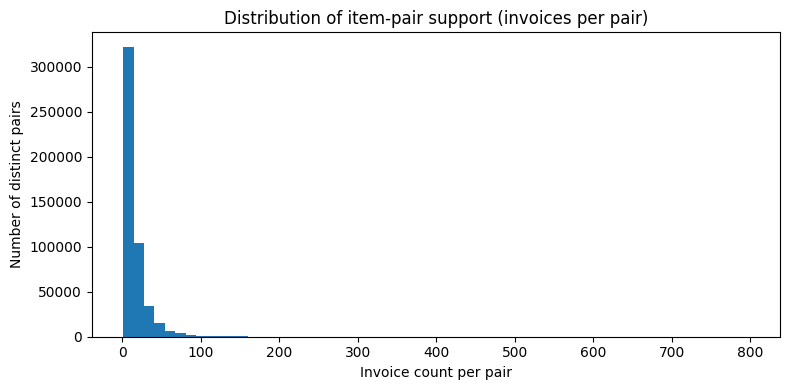

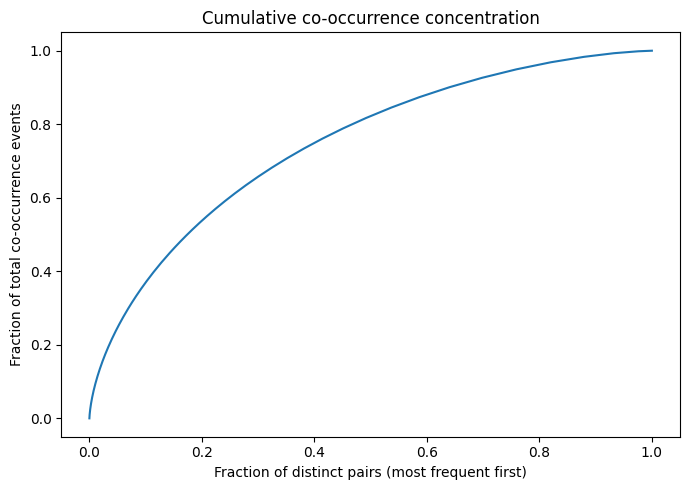

In [9]:
# Plot 1: distribution of pair supports
plt.figure(figsize=(8, 4))
plt.hist(res["pair_support"]["invoice_count"], bins=60)
plt.title("Distribution of item-pair support (invoices per pair)")
plt.xlabel("Invoice count per pair")
plt.ylabel("Number of distinct pairs")
plt.tight_layout()
plt.show()

# Plot 2: concentration curve
ps = res["pair_support_sorted"]
plt.figure(figsize=(7, 5))
plt.plot(ps["cum_pairs_frac"], ps["cum_support_frac"])
plt.title("Cumulative co-occurrence concentration")
plt.xlabel("Fraction of distinct pairs (most frequent first)")
plt.ylabel("Fraction of total co-occurrence events")
plt.tight_layout()
plt.show()

In [10]:
# Meaningful tests
def _make_item_support_from_invoice_item(invoice_item: pd.DataFrame) -> pd.DataFrame:
    """
    Helper for tests: build item_support with invoice_count from a deduped invoice_item.
    """
    tmp = invoice_item.copy()
    tmp["StockCode"] = tmp["StockCode"].astype(str)
    tmp["InvoiceNo"] = tmp["InvoiceNo"].astype(str)

    return (
        tmp.groupby("StockCode")["InvoiceNo"]
        .nunique()
        .rename("invoice_count")
        .to_frame()
        .sort_values("invoice_count", ascending=False)
    )

def test_pair_support_counts_unique_pairs_per_invoice():
    """
    Verifies that:
    - Co-occurring pairs are counted by number of invoices (support).
    - Duplicates inside an invoice do not inflate counts if invoice_item is deduped.
    """
    invoice_item = pd.DataFrame(
        {
            "InvoiceNo": ["A", "A", "A", "B", "B", "C"],
            "StockCode": ["1", "2", "3", "1", "2", "1"],
        }
    ).drop_duplicates()

    item_support = _make_item_support_from_invoice_item(invoice_item)

    res = compute_cooccurrence_sparsity(
        invoice_item=invoice_item,
        item_support=item_support,
        top_m_items=3,              # keep items 1,2,3
        max_basket_for_pairs=200,
    )

    ps = res["pair_support"].set_index(["StockCode_a", "StockCode_b"])["invoice_count"]

    # Invoice A has pairs: (1,2), (1,3), (2,3)
    # Invoice B has pair: (1,2)
    # Invoice C has no pairs (single item)
    assert int(ps.loc[("1", "2")]) == 2
    assert int(ps.loc[("1", "3")]) == 1
    assert int(ps.loc[("2", "3")]) == 1

    # Distinct pairs observed should be 3 among items {1,2,3}
    summary = res["summary"].set_index("metric")["value"]
    assert int(summary["distinct_pairs_observed (basket_size<=cap)"]) == 3


def test_sparsity_metrics_match_expected_small_graph():
    """
    For 4 items, possible distinct unordered pairs is 6.
    Construct invoices so only 2 distinct pairs appear.
    Coverage = 2/6, sparsity = 1 - 2/6 = 4/6.
    """
    invoice_item = pd.DataFrame(
        {
            "InvoiceNo": ["A", "A", "B", "B", "C", "C"],
            "StockCode": ["1", "2", "1", "2", "3", "4"],  # pairs (1,2) and (3,4)
        }
    ).drop_duplicates()

    item_support = _make_item_support_from_invoice_item(invoice_item)

    res = compute_cooccurrence_sparsity(
        invoice_item=invoice_item,
        item_support=item_support,
        top_m_items=4,
        max_basket_for_pairs=200,
    )

    summary = res["summary"].set_index("metric")["value"]
    assert int(summary["n_items (top-M unique)"]) == 4
    assert int(summary["possible_distinct_pairs"]) == 6
    assert int(summary["distinct_pairs_observed (basket_size<=cap)"]) == 2

    coverage = float(summary["distinct_pair_coverage"])
    sparsity = float(summary["distinct_pair_sparsity"])
    assert np.isclose(coverage, 2 / 6)
    assert np.isclose(sparsity, 1 - 2 / 6)


def test_top_m_filter_and_basket_cap_change_results_as_expected():
    """
    Verifies both controls work:
    - top_m_items: restricting items removes pairs involving excluded items.
    - max_basket_for_pairs: excluding large baskets removes pair observations from those baskets.
    """
    # Invoice A has 3 items (1,2,3) => contributes 3 pairs
    # Invoice B has 2 items (1,2)   => contributes 1 pair (1,2)
    invoice_item = pd.DataFrame(
        {
            "InvoiceNo": ["A", "A", "A", "B", "B"],
            "StockCode": ["1", "2", "3", "1", "2"],
        }
    ).drop_duplicates()

    item_support = _make_item_support_from_invoice_item(invoice_item)

    # Case 1: top_m_items=2 keeps only items 1 and 2, so (1,3) and (2,3) pairs disappear
    res_top2 = compute_cooccurrence_sparsity(
        invoice_item=invoice_item,
        item_support=item_support,
        top_m_items=2,
        max_basket_for_pairs=200,
    )
    pairs_top2 = set(map(tuple, res_top2["pair_support"][["StockCode_a", "StockCode_b"]].values))
    assert pairs_top2 == {("1", "2")}

    # Case 2: cap baskets at size<=2 excludes Invoice A, leaving only Invoice B
    res_cap2 = compute_cooccurrence_sparsity(
        invoice_item=invoice_item,
        item_support=item_support,
        top_m_items=3,
        max_basket_for_pairs=2,
    )
    ps_cap2 = res_cap2["pair_support"].set_index(["StockCode_a", "StockCode_b"])["invoice_count"]
    assert int(ps_cap2.loc[("1", "2")]) == 1
    assert ("1", "3") not in ps_cap2.index
    assert ("2", "3") not in ps_cap2.index

test_pair_support_counts_unique_pairs_per_invoice()
test_sparsity_metrics_match_expected_small_graph()
test_top_m_filter_and_basket_cap_change_results_as_expected()
print("All tests passed")

All tests passed


I first measured how often items appear together in the same basket.To keep the computation manageable and focus on stable patterns, I limited the analysis to the top 1,000 most common items. When building the pairs, I also ignored very large baskets above 200 unique items. Then I created a metric table to summarizes the overall scale and coverage of co-occurrence and a top pair table to list the most frequent item pairs. I also created a pair support histogram to show the full distribution of pair frequencies, and a cumulative co-occurrence concentration curve to show how much of all co-occurrence activity is explained by the most frequent pairs. <br><br>
From the metric table, we can see that within the top 1000 items there are 499500 possible item pairs, and we can find about 492425 of them at least once, which is about 98.6 percent coverage. This means that with almost 19.3k invoices, nearly every pair among popular items happens at least one time somewhere. Moreover, the total pair events is about 12.2 million, which explains why coverage becomes so high. <br><br>
From the top pair table, we can find that many of those pairs that show up together frequently look like matching products or products from the same family, such as related bag variants and product sets. For example, pairs involving 85099B appear repeatedly, which suggests 85099B is a common "anchor" item that is often bought with several other popular items. <br><br>
By looking at the pair support histogram, we can see that it is very right-skewed. Most pairs occur together in only a small number of invoices, and then there is a long tail where a small number of pairs occur together hundreds of times. So even though almost all pairs exist at least once, most of them are weak, and only a small group of pairs are truly frequent. <br><br>
As for the cumulative co-occurrence concentration curve, it rises quickly at the start and then flattens out. This means a small fraction of the most frequent pairs accounts for a large fraction of all co-occurrence events. In simple terms, most of the "together" signal in the data is driven by a relatively small set of strong pairs, while the huge number of other pairs contribute very little.

On my honor, I declare the following resources:
1. AI Tools:
- ChatGPT: I asked it to write a function for item co-occurance sparsity  analysis and created tables and plots as needed. Next, I asked it to generate three meaningful tests to test that the function works. I also provided the results to it to ask for suggestions for intepretation.

### 5. Temporal gaps between transactions

In [11]:
def temporal_gaps_between_transactions(
    df_purchase: pd.DataFrame,
    time_col: str = "InvoiceDate",
    customer_col: str = "CustomerID",
    invoice_col: str = "InvoiceNo",
    country_col: str = "Country",
    min_invoices_per_customer: int = 2,
) -> dict:
    """
    Compute temporal gaps between transactions (in days) for each customer.

    Returns dict with:
    - invoice_times: one row per invoice with timestamp and customer
    - gaps: one row per (customer, consecutive invoice) gap in days
    - gap_summary: overall summary stats
    - gap_quantiles: selected quantiles
    - gaps_by_country: summary by country (optional if country_col exists)
    """
    # Validate required columns
    for c in [time_col, invoice_col, customer_col]:
        if c not in df_purchase.columns:
            raise ValueError(f"Missing required column: {c}")

    # One row per invoice (transaction)
    inv = (
        df_purchase[[invoice_col, customer_col, time_col] + ([country_col] if country_col in df_purchase.columns else [])]
        .drop_duplicates(subset=[invoice_col])
        .copy()
    )

    # Parse time
    inv[time_col] = pd.to_datetime(inv[time_col], errors="coerce")

    # Drop invoices with missing timestamp
    inv = inv.dropna(subset=[time_col])

    # Drop missing customer IDs (can't compute per-customer gaps)
    inv = inv.dropna(subset=[customer_col])

    # Normalize types
    inv[invoice_col] = inv[invoice_col].astype(str)
    inv[customer_col] = inv[customer_col].astype(str)

    # Keep only customers with at least min_invoices_per_customer invoices
    counts = inv.groupby(customer_col)[invoice_col].nunique()
    keep_customers = counts[counts >= min_invoices_per_customer].index
    inv = inv.loc[inv[customer_col].isin(keep_customers)].copy()

    # Sort invoices per customer, compute gaps in days between consecutive invoices
    inv = inv.sort_values([customer_col, time_col, invoice_col])

    inv["prev_time"] = inv.groupby(customer_col)[time_col].shift(1)
    inv["gap_days"] = (inv[time_col] - inv["prev_time"]).dt.total_seconds() / (24 * 3600)

    gaps = inv.dropna(subset=["gap_days"]).copy()

    # Summary tables
    def _summary(s: pd.Series) -> pd.DataFrame:
        return pd.DataFrame({
            "n_gaps": [int(s.shape[0])],
            "mean_days": [float(s.mean())],
            "std_days": [float(s.std(ddof=1))],
            "min_days": [float(s.min())],
            "median_days": [float(s.median())],
            "max_days": [float(s.max())],
        })

    gap_summary = _summary(gaps["gap_days"])

    gap_quantiles = (
        gaps["gap_days"]
        .quantile([0.5, 0.75, 0.9, 0.95, 0.99])
        .rename_axis("quantile")
        .reset_index(name="gap_days")
    )

    return {
        "invoice_times": inv,
        "gaps": gaps[[customer_col, invoice_col, time_col, "prev_time", "gap_days"] + ([country_col] if country_col in inv.columns else [])].copy(),
        "gap_summary": gap_summary,
        "gap_quantiles": gap_quantiles,
    }

In [12]:
res = temporal_gaps_between_transactions(df_purchase)

display(res["gap_summary"])
display(res["gap_quantiles"])

,n_gaps,mean_days,std_days,min_days,median_days,max_days
0,14194,39.966909,51.888252,0.0,21.919097,365.981944


,quantile,gap_days
0,0.50,21.919097
1,0.75,51.038021
2,0.90,103.026667
3,0.95,146.174271
4,0.99,252.011819


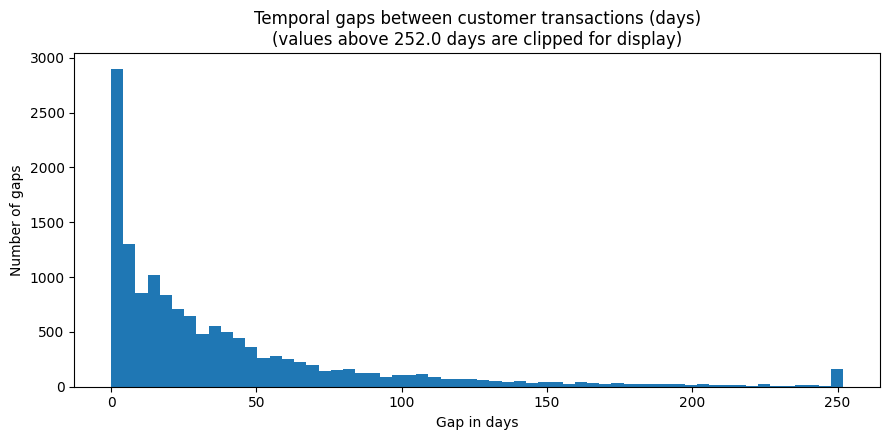

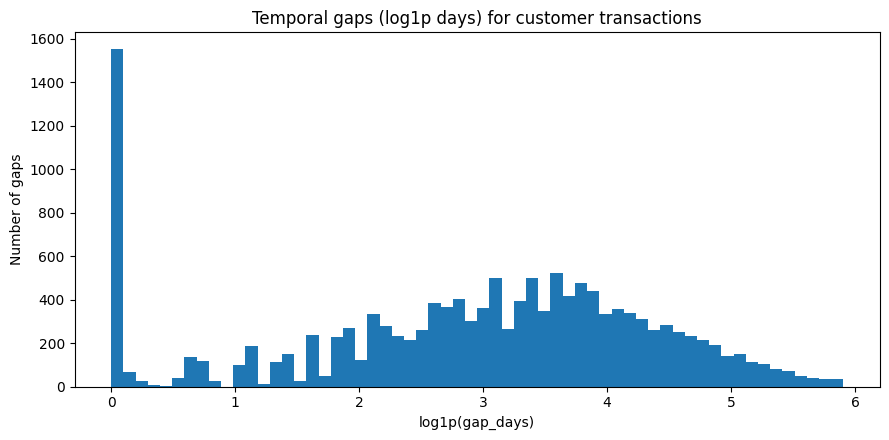

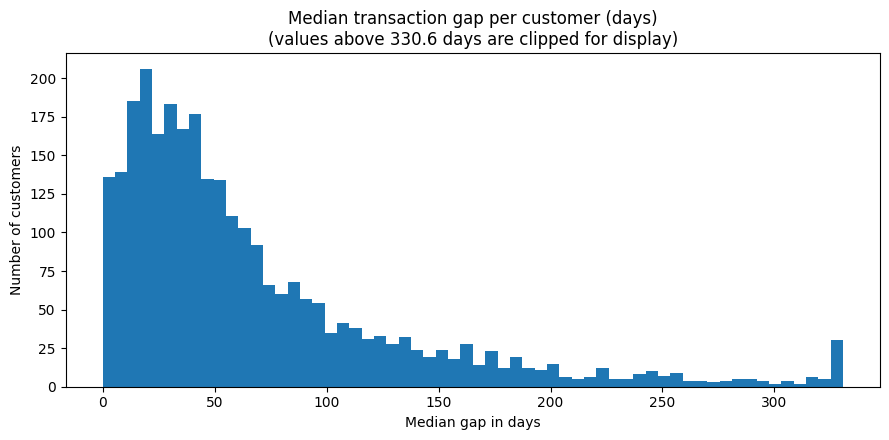

In [13]:
# Plot 1: histogram of gaps (clip at 99th percentile for readability)
g = res["gaps"]["gap_days"]
cap = float(g.quantile(0.99))
g_clip = g.clip(upper=cap)

plt.figure(figsize=(9, 4.5))
plt.hist(g_clip, bins=60)
plt.title(f"Temporal gaps between customer transactions (days)\n(values above {cap:.1f} days are clipped for display)")
plt.xlabel("Gap in days")
plt.ylabel("Number of gaps")
plt.tight_layout()
plt.show()

# Plot 2: log-scaled gaps (helps show short vs long gaps together)
g_pos = g[g > 0]
plt.figure(figsize=(9, 4.5))
plt.hist(np.log1p(g_pos), bins=60)
plt.title("Temporal gaps (log1p days) for customer transactions")
plt.xlabel("log1p(gap_days)")
plt.ylabel("Number of gaps")
plt.tight_layout()
plt.show()

# Plot 3: per-customer typical gap (median gap per customer)
cust_median = res["gaps"].groupby("CustomerID")["gap_days"].median()
cap2 = float(cust_median.quantile(0.99))
plt.figure(figsize=(9, 4.5))
plt.hist(cust_median.clip(upper=cap2), bins=60)
plt.title(f"Median transaction gap per customer (days)\n(values above {cap2:.1f} days are clipped for display)")
plt.xlabel("Median gap in days")
plt.ylabel("Number of customers")
plt.tight_layout()
plt.show()

In [14]:
# Meaningful tests
def test_gaps_are_computed_correctly_for_single_customer():
    """
    Customer with 3 invoices at known times should produce 2 gaps with correct day values.
    """
    df_purchase = pd.DataFrame(
        {
            "InvoiceNo": ["A1", "A2", "A3"],
            "CustomerID": ["1", "1", "1"],
            "InvoiceDate": [
                "2011-01-01 10:00:00",
                "2011-01-03 10:00:00",
                "2011-01-06 10:00:00",
            ],
            "Country": ["UK", "UK", "UK"],
            "Quantity": [1, 1, 1],
            "UnitPrice": [1.0, 1.0, 1.0],
        }
    )

    res = temporal_gaps_between_transactions(df_purchase, min_invoices_per_customer=2)

    gaps = res["gaps"].sort_values(["CustomerID", "InvoiceDate", "InvoiceNo"]).reset_index(drop=True)
    assert gaps.shape[0] == 2

    # Gaps: Jan 3 - Jan 1 = 2 days, Jan 6 - Jan 3 = 3 days
    assert np.isclose(float(gaps.loc[0, "gap_days"]), 2.0)
    assert np.isclose(float(gaps.loc[1, "gap_days"]), 3.0)

    # Summary should reflect these two gaps
    summary = res["gap_summary"].iloc[0].to_dict()
    assert summary["n_gaps"] == 2
    assert np.isclose(summary["mean_days"], 2.5)


def test_deduplication_is_one_row_per_invoice():
    """
    Multiple line items for the same invoice should not create extra transactions.
    Deduplication should treat each InvoiceNo as a single transaction timestamp.
    """
    df_purchase = pd.DataFrame(
        {
            "InvoiceNo": ["B1", "B1", "B2", "B2"],
            "CustomerID": ["2", "2", "2", "2"],
            "InvoiceDate": [
                "2011-02-01 09:00:00",
                "2011-02-01 09:00:00",
                "2011-02-05 09:00:00",
                "2011-02-05 09:00:00",
            ],
            "Quantity": [1, 2, 1, 3],
            "UnitPrice": [1.0, 1.0, 1.0, 1.0],
        }
    )

    res = temporal_gaps_between_transactions(df_purchase, min_invoices_per_customer=2)
    inv = res["invoice_times"]

    # Should have exactly 2 invoices after dropping duplicate InvoiceNo rows
    assert inv["InvoiceNo"].nunique() == 2

    gaps = res["gaps"]
    assert gaps.shape[0] == 1
    assert np.isclose(float(gaps["gap_days"].iloc[0]), 4.0)


def test_filters_missing_customer_and_min_invoices_threshold():
    """
    Customers with missing CustomerID should be dropped.
    Customers with fewer than min_invoices_per_customer invoices should be excluded.
    """
    df_purchase = pd.DataFrame(
        {
            "InvoiceNo": ["C1", "C2", "D1", "E1", "E2"],
            "CustomerID": ["3", "3", "4", None, None],
            "InvoiceDate": [
                "2011-03-01 00:00:00",
                "2011-03-10 00:00:00",
                "2011-03-05 00:00:00",
                "2011-03-02 00:00:00",
                "2011-03-07 00:00:00",
            ],
            "Quantity": [1, 1, 1, 1, 1],
            "UnitPrice": [1.0, 1.0, 1.0, 1.0, 1.0],
        }
    )

    # min_invoices_per_customer=2 keeps only customer "3"
    res = temporal_gaps_between_transactions(df_purchase, min_invoices_per_customer=2)
    inv = res["invoice_times"]
    gaps = res["gaps"]

    assert set(inv["CustomerID"].unique()) == {"3"}
    assert inv["InvoiceNo"].nunique() == 2
    assert gaps.shape[0] == 1
    assert np.isclose(float(gaps["gap_days"].iloc[0]), 9.0)

test_gaps_are_computed_correctly_for_single_customer()
test_deduplication_is_one_row_per_invoice()
test_filters_missing_customer_and_min_invoices_threshold()

print("All tests passed")

All tests passed


I measured temporal gaps between transactions by first collapsing the purchase-only data to one row per invoice with its `InvoiceDate` and `CustomerID`. Then I sort invoices within each customer and takes the time difference in days between each pair of consecutive purchases. When computing the gaps, I only did for customers with at least two invoices, and I also dropped rows with missing `CustomerID` because we cannot track repeat pruchases for anonymous customers. Next, I created a summary table to give a quick overall picture of the typical gap length and how spread out gaps are across the dataset. I also created a quantile table to show the gap distribution. Besides, I plotted a gap histogram, a log1p gap histogram, and a per-customer median gap histogram to get a complementary view of the temporal gaps. <br><br>
From the summary table and the quantile table, we can see that gaps are highly right-skewed, which means that many repeat purchases happen quickly but some customers return after a long time. The median gap is about 21.9 days, while the mean is larger at about 40.0 days, which happens because long gaps pull the average up. The quantiles show that 75 percent of gaps are within about 51 days, 90 percent are within about 103 days, and 99 percent are within about 252 days, with the longest gaps close to 366 days, which suggests a mix of frequent shoppers and occasional, seasonal, or one-off customers. <br><br>
By looking at the plots, we can find that the clipped gap histogram shows a very large spike near zero and then a long tail, which indicates that many repeat purchases happen within a few days, but there are also many customers who come back weeks or months later. The log1p plot makes this clearer by spreading out the short gaps and shows that short gaps dominate but there is still a wide range of medium gaps. The per-customer median gap plot shows most customers have a median gap in the tens of days, while a smaller group has median gaps well over 100 days, which matches the quantiles and suggests a mix of frequent shoppers and occasional or seasonal shoppers.

On my honor, I declare the following resources:
1. AI Tools:
- ChatGPT: I asked it to write a function for transactions temporal gaps analysis and created tables and plots as needed. Next, I asked it to generate three meaningful tests to test that the function works. I also provided the results to it to ask for suggestions for intepretation.

## E. Initial Insights and Direction

- Observation <br><br>
From the EDA, we can find that item frequency and co-occurance strength are very uneven. Most items appear in a few invoices, and most item pairs occur together only a small number of times, even within the top items. Meanwhile, a small set of pairs appears together hundreds of times and drives a large share of all co-occurrence events. <br><br>
The transaction timing is also skewed. Many customers make repeat purchases within a short time, but there is a long tail of gaps where customers return after weeks or months. Customers also differ a lot in their typical shopping gap. <br><br>
- Hypothesis <br><br>
For the frequent itemsets and association rule mining, we can find that using one support threshold for everything might not work well. If the threshold is high, we will mostly find rules about the most popular items and the strongest pairs. If the threshold is low, we might get many weak rules that happen by chance. A better plan is to tune support with the long tail in mind, and use simple time limits when we mine sequences. As for the beyond-course technique, we should use sequential pattern mining to explore repeat buying habits that basket rules miss, especially if we split customers into frequent buyers and occasional buyers. <br><br>
- Potential RQs:
  1. Does filtering to top items, or removing a few very common "anchor" items, produce rules that are more diverse and more useful?
  2. How similar are the strongest co-occurring pairs to the strongest association rules, and do they mostly reflect product families and bundles?
  3. Do sequential patterns over customer purchase history reveal item relationships that are not visible from unordered baskets?
  4. Do frequent shoppers and occasional shoppers show different sequential patterns, and does segmenting customers by typical gap improve pattern clarity and stability?

On my honor, I declare the following resources:
1. AI Tools:
- ChatGPT: I provided the observations and hypothesis to it to ask it to suggest some research questions based on the topics of frequent itemsets and association rules mining, and sequential pattern mining.

## F. GitHub Portfolio Building

- GitHub Repo Link: https://github.com/sqz0914/CSCE-676-Project